<div style="background:linear-gradient(135deg,#4F46E5 0%,#7E22CE 100%);color:#fff;padding:28px 32px;border-radius:12px;font-family:'IBM Plex Sans',system-ui,sans-serif;">
  <div style="font-family:'IBM Plex Mono',monospace;font-size:13px;letter-spacing:1px;opacity:.85;">INF672 · MACHINE LEARNING · FUNDAMENTOS MATEMÁTICOS</div>
  <h1 style="margin:8px 0 4px 0;font-size:30px;font-weight:600;">Derivada y Gradiente</h1>
  <div style="opacity:.9;font-size:15px;">De la pendiente de una recta al motor que entrena un modelo</div>
</div>

### Objetivos del cuaderno

- Entender la **derivada** como razón de cambio y pendiente de la recta tangente.
- Calcular derivadas **a mano** con las reglas fundamentales.
- Extender la idea a varias variables: **derivadas parciales**.
- Construir el **gradiente** y comprender por qué apunta en la dirección de máximo ascenso.
- Ver el **descenso de gradiente** como la idea que hace posible entrenar modelos.

> En este cuaderno **todas las derivadas se obtienen analíticamente** (a mano). El código de Python se usa *solo para visualizar* fórmulas que ya derivamos nosotros — nunca para calcular la derivada por ti.

---
## 0 · ¿Por qué le importa la derivada al *Machine Learning*?

Un modelo aprende ajustando sus parámetros para que su error sea lo más pequeño posible. Pero, ante millones de combinaciones posibles, surge la pregunta clave:

> **¿Cómo sabe el modelo hacia qué lado mover cada parámetro para reducir el error?**

La respuesta es la **derivada**. Ella nos dice, en cada punto, *hacia dónde y qué tan rápido* cambia una función. Cuando la función tiene varias variables (como los muchos parámetros de un modelo), la generalización de la derivada es el **gradiente**. Guardemos esta pregunta: al final del cuaderno la habremos respondido.

---
## 1 · Preparación del entorno

Fijamos la paleta de la materia y unos ajustes de estilo para las gráficas.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (habilita proyección 3D)

# Paleta INF672 — "cuaderno científico"
INDIGO  = "#4F46E5"
PURPURA = "#7E22CE"
CORAL   = "#F43F5E"
TINTA   = "#111827"

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"]      = True
plt.rcParams["grid.alpha"]     = 0.3
plt.rcParams["font.size"]      = 11
plt.rcParams["axes.edgecolor"] = "#9CA3AF"

print("Entorno listo ✓")

Entorno listo ✓


---
## 2 · La derivada en una variable

### 2.1 · La idea intuitiva

La derivada mide la **razón de cambio** de una función: cuánto cambia la salida $f(x)$ cuando movemos un poquito la entrada $x$. Geométricamente, es la **pendiente de la recta tangente** a la curva en un punto.

<div style="border-left:4px solid #4F46E5;background:#EEF2FF;padding:12px 16px;border-radius:4px;margin:6px 0;font-family:'IBM Plex Sans',system-ui,sans-serif;"><strong style="color:#4F46E5;font-family:'IBM Plex Mono',monospace;font-size:12px;letter-spacing:1px;">DEFINICIÓN</strong><br>La derivada de $f$ en $x$ es el límite del cociente de diferencias:
$$f'(x) = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$
Si el límite existe, mide la pendiente instantánea de la curva en ese punto.</div>

### 2.2 · Derivamos $f(x) = x^2$ a mano, desde la definición

Sustituimos en el límite y simplificamos paso a paso:

$$
f'(x) = \lim_{h \to 0} \frac{(x+h)^2 - x^2}{h}
      = \lim_{h \to 0} \frac{x^2 + 2xh + h^2 - x^2}{h}
$$

$$
      = \lim_{h \to 0} \frac{2xh + h^2}{h}
      = \lim_{h \to 0} (2x + h)
      = \boxed{\,2x\,}
$$

El término $h$ desaparece al tomar el límite. Concluimos que la pendiente de $f(x)=x^2$ en cualquier punto es $f'(x) = 2x$.

### 2.3 · Reglas de derivación (nuestra caja de herramientas)

Derivar desde el límite cada vez sería agotador. Estas reglas, demostrables con el mismo límite, nos permiten derivar rápido y a mano:

| Regla | Función $f(x)$ | Derivada $f'(x)$ |
|-------|----------------|-------------------|
| Constante | $c$ | $0$ |
| Potencia | $x^{n}$ | $n\,x^{n-1}$ |
| Múltiplo | $c\,g(x)$ | $c\,g'(x)$ |
| Suma | $g(x)+h(x)$ | $g'(x)+h'(x)$ |
| Producto | $g(x)\,h(x)$ | $g'h + g\,h'$ |
| Cociente | $\dfrac{g}{h}$ | $\dfrac{g'h - g\,h'}{h^{2}}$ |
| Cadena | $g(h(x))$ | $g'(h(x))\cdot h'(x)$ |

<div style="border-left:4px solid #059669;background:#ECFDF5;padding:12px 16px;border-radius:4px;margin:6px 0;font-family:'IBM Plex Sans',system-ui,sans-serif;"><strong style="color:#059669;font-family:'IBM Plex Mono',monospace;font-size:12px;letter-spacing:1px;">EJEMPLO</strong><br><b>Regla de la potencia.</b> Para $f(x)=x^3$ aplicamos $n\,x^{n-1}$ con $n=3$:
$$f'(x) = 3x^{2}$$</div>

<div style="border-left:4px solid #059669;background:#ECFDF5;padding:12px 16px;border-radius:4px;margin:6px 0;font-family:'IBM Plex Sans',system-ui,sans-serif;"><strong style="color:#059669;font-family:'IBM Plex Mono',monospace;font-size:12px;letter-spacing:1px;">EJEMPLO</strong><br><b>Regla de la cadena.</b> Para $f(x) = (2x+1)^3$ tomamos la función externa $u^3$ y la interna $u = 2x+1$:
$$\frac{df}{dx} = \frac{df}{du}\cdot\frac{du}{dx} = 3u^{2}\cdot 2 = 6\,(2x+1)^{2}$$</div>

### 2.4 · Visualicemos la tangente

Ya derivamos **a mano** que para $f(x)=x^2$ se cumple $f'(x)=2x$. El código de abajo *solo dibuja* esa fórmula: usa nuestra pendiente para trazar la recta tangente en $x_0 = 1.5$.

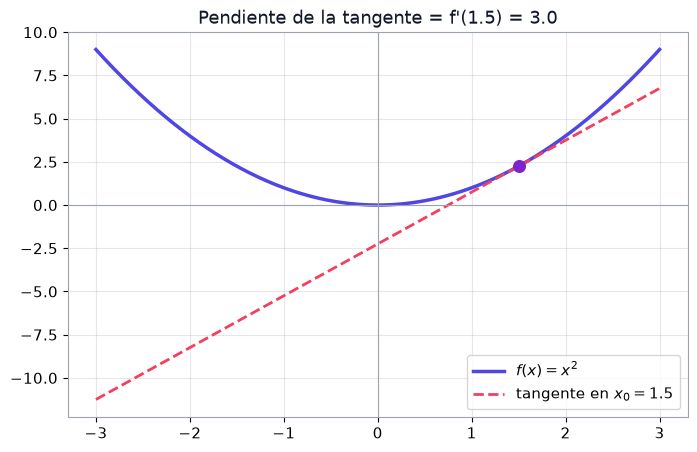

In [2]:
f  = lambda x: x**2      # función
fp = lambda x: 2*x       # derivada obtenida A MANO: f'(x) = 2x

x0 = 1.5
x  = np.linspace(-3, 3, 400)
tangente = f(x0) + fp(x0) * (x - x0)   # recta: y = f(x0) + f'(x0)(x - x0)

plt.plot(x, f(x), color=INDIGO, lw=2.5, label=r"$f(x)=x^2$")
plt.plot(x, tangente, color=CORAL, lw=2, ls="--",
         label=fr"tangente en $x_0={x0}$")
plt.scatter([x0], [f(x0)], color=PURPURA, s=70, zorder=5)
plt.axhline(0, color="#9CA3AF", lw=0.8); plt.axvline(0, color="#9CA3AF", lw=0.8)
plt.title(f"Pendiente de la tangente = f'({x0}) = {fp(x0)}", color=TINTA)
plt.legend(); plt.show()

<div style="border-left:4px solid #7E22CE;
            background:#F5F3FF;
            padding:12px 16px;
            border-radius:4px;
            margin:6px 0;
            font-family:'IBM Plex Sans',system-ui,sans-serif;
            line-height:1.6;">

<strong style="color:#7E22CE;
               font-family:'IBM Plex Mono',monospace;
               font-size:12px;
               letter-spacing:1px;">NOTA</strong>

<p style="margin:8px 0;">
El <strong>signo</strong> de la derivada tiene una lectura directa:
</p>

<ul style="margin:6px 0 8px 20px; padding:0;">
<li>$f'(x) > 0$ → la función <b>crece</b>.</li>
<li>$f'(x) < 0$ → la función <b>decrece</b>.</li>
<li>$f'(x) = 0$ → punto <b>crítico</b> (posible máximo o mínimo).</li>
</ul>

<p style="margin:8px 0 0;">
Esta última condición, $f'(x)=0$, es la que buscamos al minimizar el error de un modelo.
</p>

</div>

---
## 3 · Varias variables: derivadas parciales

Los modelos reales dependen de **muchos** parámetros a la vez. Necesitamos derivar funciones como $f(x, y)$. La herramienta es la **derivada parcial**: derivamos respecto a *una* variable **tratando a las demás como constantes**.

<div style="border-left:4px solid #4F46E5;background:#EEF2FF;padding:12px 16px;border-radius:4px;margin:6px 0;font-family:'IBM Plex Sans',system-ui,sans-serif;"><strong style="color:#4F46E5;font-family:'IBM Plex Mono',monospace;font-size:12px;letter-spacing:1px;">DEFINICIÓN</strong><br>Las derivadas parciales de $f(x,y)$ son:
$$\frac{\partial f}{\partial x}:\ \text{derivar respecto a } x \text{ con } y \text{ fija,}
\qquad
\frac{\partial f}{\partial y}:\ \text{derivar respecto a } y \text{ con } x \text{ fija.}$$</div>

### 3.1 · Derivamos $f(x,y) = x^2 + xy + y^2$ a mano

**Respecto a $x$** (tratamos $y$ como constante):

- $\dfrac{\partial}{\partial x}(x^2) = 2x$
- $\dfrac{\partial}{\partial x}(xy) = y$ &nbsp; (como $y$ es constante, $xy$ es "constante $\times x$")
- $\dfrac{\partial}{\partial x}(y^2) = 0$ &nbsp; (no contiene $x$)

$$\boxed{\ \frac{\partial f}{\partial x} = 2x + y\ }$$

**Respecto a $y$** (tratamos $x$ como constante):

- $\dfrac{\partial}{\partial y}(x^2) = 0$
- $\dfrac{\partial}{\partial y}(xy) = x$
- $\dfrac{\partial}{\partial y}(y^2) = 2y$

$$\boxed{\ \frac{\partial f}{\partial y} = x + 2y\ }$$

### 3.2 · Visualicemos la función de dos variables

Una función $f(x,y)$ es una **superficie**. Sus **curvas de nivel** (como en un mapa topográfico) unen puntos de igual altura.

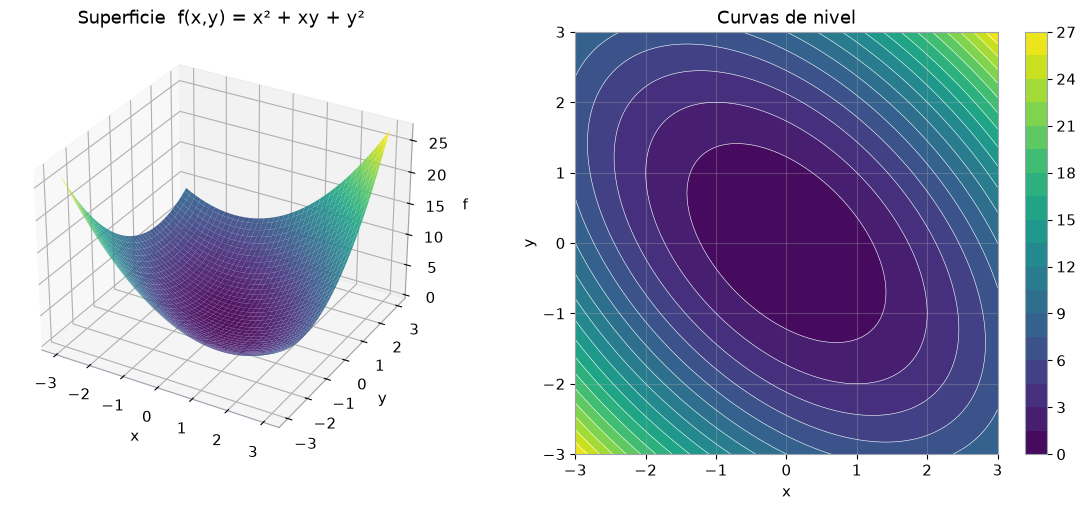

In [3]:
f2 = lambda x, y: x**2 + x*y + y**2

x = np.linspace(-3, 3, 120)
y = np.linspace(-3, 3, 120)
X, Y = np.meshgrid(x, y)
Z = f2(X, Y)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.plot_surface(X, Y, Z, cmap="viridis", alpha=0.92)
ax1.set_title("Superficie  f(x,y) = x² + xy + y²")
ax1.set_xlabel("x"); ax1.set_ylabel("y"); ax1.set_zlabel("f")

ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contourf(X, Y, Z, levels=20, cmap="viridis")
ax2.contour(X, Y, Z, levels=20, colors="white", linewidths=0.4)
ax2.set_title("Curvas de nivel"); ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.set_aspect("equal")
fig.colorbar(cs, ax=ax2)
plt.tight_layout(); plt.show()

---
## 4 · El gradiente

Reunimos las derivadas parciales en un **vector**. Ese vector es el gradiente, y es la generalización natural de la derivada a varias variables.

<div style="border-left:4px solid #4F46E5;background:#EEF2FF;padding:12px 16px;border-radius:4px;margin:6px 0;font-family:'IBM Plex Sans',system-ui,sans-serif;"><strong style="color:#4F46E5;font-family:'IBM Plex Mono',monospace;font-size:12px;letter-spacing:1px;">DEFINICIÓN</strong><br>El <strong>gradiente</strong> de $f(x,y)$ es el vector de sus derivadas parciales:
$$\nabla f(x,y) = \left( \frac{\partial f}{\partial x},\ \frac{\partial f}{\partial y} \right)$$
En un punto dado, $\nabla f$ <strong>apunta en la dirección de máximo crecimiento</strong> de la función y es <strong>perpendicular</strong> a la curva de nivel que pasa por ese punto.</div>

### 4.1 · Escribimos el gradiente a mano

Con las parciales que ya calculamos para $f(x,y)=x^2+xy+y^2$:

$$\nabla f(x,y) = \big(\,2x + y,\ \ x + 2y\,\big)$$

Evaluado, por ejemplo, en el punto $(1, 1)$:

$$\nabla f(1,1) = \big(2(1)+1,\ \ 1+2(1)\big) = (3,\ 3)$$

Es decir: parados en $(1,1)$, la dirección de mayor ascenso apunta hacia $(3,3)$ (arriba y a la derecha).

### 4.2 · Visualicemos el campo del gradiente

Dibujamos una flecha $\nabla f$ en cada punto sobre las curvas de nivel. Observa dos cosas: las flechas **apuntan cuesta arriba** y son **perpendiculares** a las curvas de nivel.

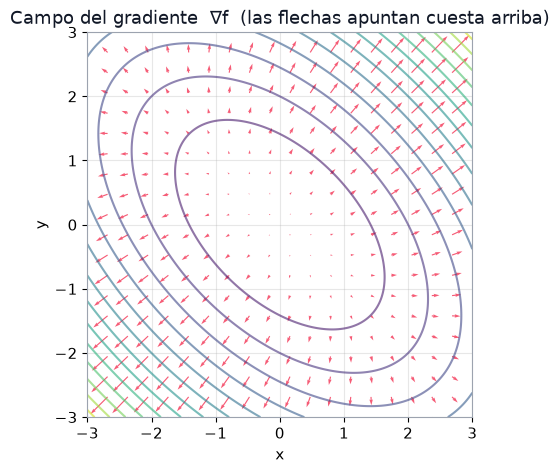

In [4]:
# Gradiente obtenido A MANO:  ∇f = (2x + y,  x + 2y)
def grad_f2(x, y):
    return 2*x + y, x + 2*y

# Malla dispersa para las flechas
xg = np.linspace(-3, 3, 20)
yg = np.linspace(-3, 3, 20)
Xg, Yg = np.meshgrid(xg, yg)
U, V = grad_f2(Xg, Yg)

# Malla fina para los contornos de fondo
xf = np.linspace(-3, 3, 200); yf = np.linspace(-3, 3, 200)
Xf, Yf = np.meshgrid(xf, yf); Zf = f2(Xf, Yf)

plt.contour(Xf, Yf, Zf, levels=15, cmap="viridis", alpha=0.6)
plt.quiver(Xg, Yg, U, V, color=CORAL, alpha=0.85)
plt.title("Campo del gradiente  ∇f  (las flechas apuntan cuesta arriba)", color=TINTA)
plt.xlabel("x"); plt.ylabel("y"); plt.gca().set_aspect("equal")
plt.show()

---
## 5 · Descenso de gradiente: la idea que entrena modelos

Si $\nabla f$ apunta hacia donde la función **más crece**, entonces $-\nabla f$ apunta hacia donde **más decrece**. Para *minimizar* (que es lo que queremos con el error), damos pasos en esa dirección opuesta.

<div style="border-left:4px solid #4F46E5;background:#EEF2FF;padding:12px 16px;border-radius:4px;margin:6px 0;font-family:'IBM Plex Sans',system-ui,sans-serif;"><strong style="color:#4F46E5;font-family:'IBM Plex Mono',monospace;font-size:12px;letter-spacing:1px;">DEFINICIÓN</strong><br><strong>Regla de actualización</strong> del descenso de gradiente:
$$\mathbf{x}_{k+1} = \mathbf{x}_{k} - \alpha\, \nabla f(\mathbf{x}_{k})$$
donde $\alpha > 0$ es la <strong>tasa de aprendizaje</strong> (learning rate): controla el tamaño del paso.</div>

### 5.1 · Dos pasos calculados a mano

Usemos la función más simple, un tazón: $f(x,y) = x^2 + y^2$, cuyo gradiente es
$$\nabla f(x,y) = (2x,\ 2y).$$

Partimos de $\mathbf{x}_0 = (4, 4)$ con $\alpha = 0.1$:

**Paso 1.** &nbsp; $\nabla f(4,4) = (8, 8)$
$$\mathbf{x}_1 = (4,4) - 0.1\,(8,8) = (4 - 0.8,\ 4 - 0.8) = (3.2,\ 3.2)$$

**Paso 2.** &nbsp; $\nabla f(3.2,3.2) = (6.4, 6.4)$
$$\mathbf{x}_2 = (3.2,3.2) - 0.1\,(6.4,6.4) = (2.56,\ 2.56)$$

Cada paso nos acerca al mínimo en $(0,0)$. El código repite exactamente esta cuenta muchas veces.

In [5]:
f3      = lambda x, y: x**2 + y**2
grad_f3 = lambda x, y: np.array([2*x, 2*y])   # ∇f = (2x, 2y), derivado a mano

punto = np.array([4.0, 4.0])   # x_0
alpha = 0.1                    # tasa de aprendizaje
trayectoria = [punto.copy()]

for _ in range(25):
    punto = punto - alpha * grad_f3(*punto)   # x_{k+1} = x_k - α ∇f(x_k)
    trayectoria.append(punto.copy())

trayectoria = np.array(trayectoria)
print("Primeros puntos:")
for i, p in enumerate(trayectoria[:3]):
    print(f"  x_{i} = ({p[0]:.3f}, {p[1]:.3f})")
print(f"  ...\n  x_25 = ({trayectoria[-1,0]:.4f}, {trayectoria[-1,1]:.4f})")

Primeros puntos:
  x_0 = (4.000, 4.000)
  x_1 = (3.200, 3.200)
  x_2 = (2.560, 2.560)
  ...
  x_25 = (0.0151, 0.0151)


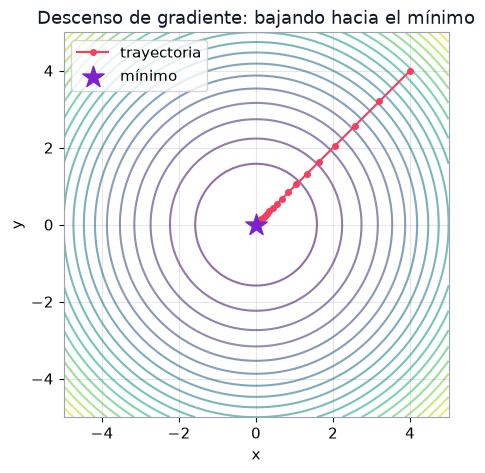

In [13]:
xf = np.linspace(-5, 5, 200); yf = np.linspace(-5, 5, 200)
Xf, Yf = np.meshgrid(xf, yf); Zf = f3(Xf, Yf)

plt.contour(Xf, Yf, Zf, levels=20, cmap="viridis", alpha=0.6)
plt.plot(trayectoria[:, 0], trayectoria[:, 1], "o-", color=CORAL, ms=4, lw=1.5,
         label="trayectoria")
plt.scatter([0], [0], marker="*", s=260, color=PURPURA, zorder=5, label="mínimo")
plt.title("Descenso de gradiente: bajando hacia el mínimo", color=TINTA)
plt.xlabel("x"); plt.ylabel("y"); plt.legend(); plt.gca().set_aspect("equal")
plt.show()

<div style="border-left:4px solid #F43F5E;background:#FFF1F2;padding:12px 16px;border-radius:4px;margin:6px 0;font-family:'IBM Plex Sans',system-ui,sans-serif;"><strong style="color:#F43F5E;font-family:'IBM Plex Mono',monospace;font-size:12px;letter-spacing:1px;">CUIDADO</strong><br>La tasa de aprendizaje $\alpha$ es delicada:
<ul style="margin:6px 0 0 0;">
<li>Si $\alpha$ es <b>demasiado grande</b>, los pasos se pasan de largo y el método puede <b>diverger</b> (oscila o se dispara).</li>
<li>Si $\alpha$ es <b>demasiado pequeña</b>, converge <b>muy lento</b>.</li>
</ul>
Elegir $\alpha$ es una de las decisiones prácticas más importantes al entrenar un modelo. <b>Experimenta:</b> cambia <code>alpha</code> a <code>0.9</code> y luego a <code>0.01</code> en la celda anterior y observa la diferencia.</div>

---
## 6 · Cierre: volvamos a la pregunta inicial

Al empezar preguntamos:

> ¿Cómo sabe el modelo hacia qué lado mover cada parámetro para reducir el error?

Ya tenemos la respuesta completa. Un modelo define una **función de error** (o *coste*) que depende de sus parámetros. Esa función es una superficie, igual que las que dibujamos. Su **gradiente** indica la dirección de máximo aumento del error; el **descenso de gradiente** da pasos en dirección contraria, $-\nabla f$, hasta llegar a un mínimo. **Entrenar un modelo es, literalmente, ejecutar descenso de gradiente** sobre su función de coste.

### Resumen

| Concepto | Idea | Fórmula clave |
|----------|------|----------------|
| Derivada | Pendiente / razón de cambio | $f'(x)=\lim_{h\to0}\frac{f(x+h)-f(x)}{h}$ |
| Derivada parcial | Derivar una variable, fijar las demás | $\frac{\partial f}{\partial x}$ |
| Gradiente | Vector de parciales; máximo ascenso | $\nabla f=(\frac{\partial f}{\partial x},\frac{\partial f}{\partial y})$ |
| Descenso de gradiente | Bajar hacia el mínimo | $\mathbf{x}_{k+1}=\mathbf{x}_k-\alpha\nabla f(\mathbf{x}_k)$ |

<div style="text-align:center;color:#6B7280;font-family:'IBM Plex Mono',monospace;font-size:12px;padding-top:12px;border-top:1px solid #E5E7EB;">
INF672 · Machine Learning · Carrera de Ingeniería Informática · Universidad Autónoma Tomás Frías
</div>